In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from datetime import datetime
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

In [41]:
flights = pd.read_csv('arquivos/AirPassengers.csv')
flights

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [42]:
print(flights.dtypes)

Month          object
#Passengers     int64
dtype: object


In [43]:
flights = pd.read_csv('arquivos/AirPassengers.csv', index_col='Month',  parse_dates=['Month'], date_format='%Y-%m')

flights

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [44]:
flights_serie_temp = flights['#Passengers']

In [45]:
valor_maximo = flights_serie_temp.max()
valor_minimo = flights_serie_temp.min()

print(f"Valor máximo: {valor_maximo}")
print(f"Valor mínimo: {valor_minimo}")

Valor máximo: 622
Valor mínimo: 104


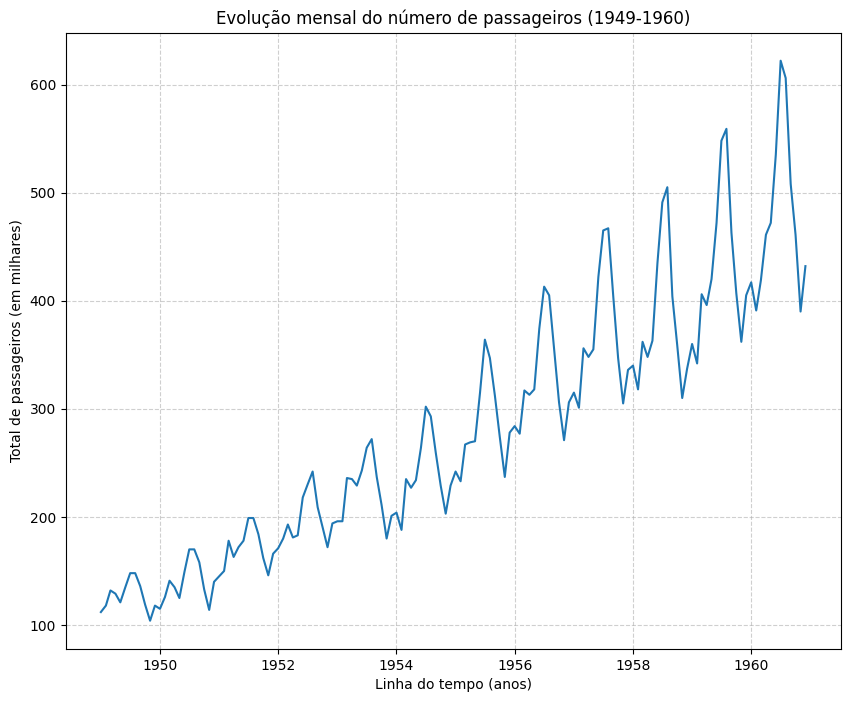

In [46]:
plt.plot(flights_serie_temp)
plt.title('Evolução mensal do número de passageiros (1949-1960)')
plt.xlabel('Linha do tempo (anos)')
plt.ylabel('Total de passageiros (em milhares)')
plt.grid(True, linestyle = '--', alpha = 0.6)
plt.show()

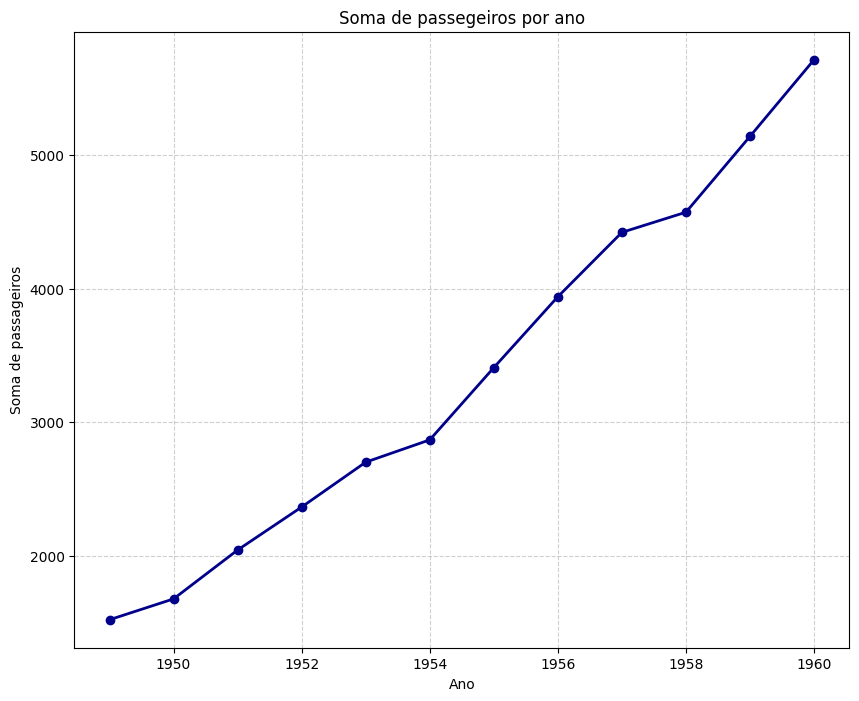

Month
1949-12-31    1520
1950-12-31    1676
1951-12-31    2042
1952-12-31    2364
1953-12-31    2700
1954-12-31    2867
1955-12-31    3408
1956-12-31    3939
1957-12-31    4421
1958-12-31    4572
1959-12-31    5140
1960-12-31    5714
Freq: YE-DEC, Name: #Passengers, dtype: int64


In [47]:
dados_por_ano = flights_serie_temp.groupby(flights_serie_temp.index.year).sum()

plt.plot(dados_por_ano, marker = 'o', color = 'darkblue', linewidth = 2)
plt.title("Soma de passegeiros por ano")
plt.xlabel('Ano')
plt.ylabel('Soma de passageiros')
plt.grid(True, linestyle = '--', alpha = 0.6)
plt.show()

print(flights_serie_temp.resample('YE').sum())


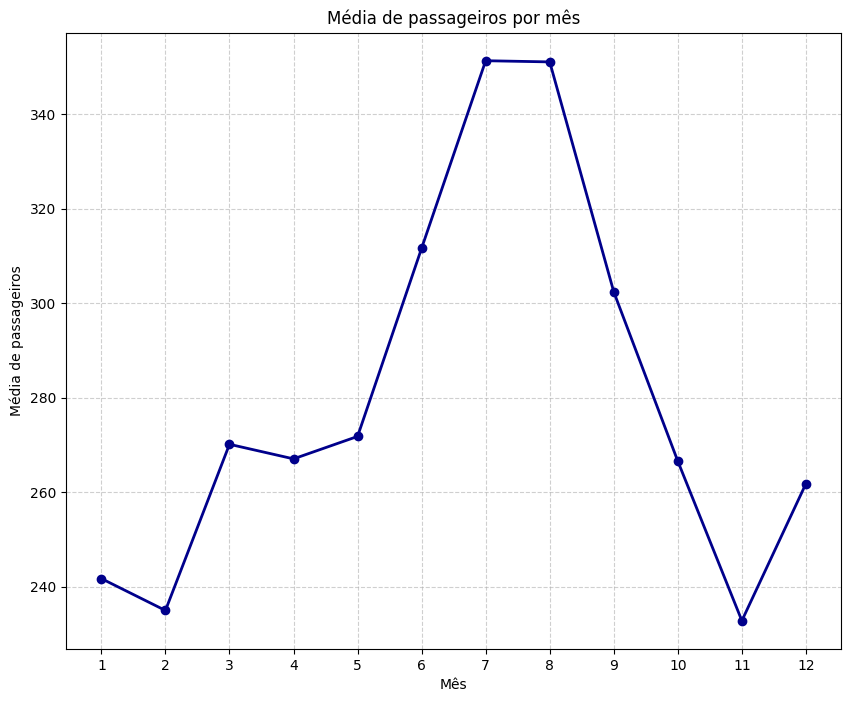

In [48]:
dados_por_mes = flights_serie_temp.groupby(flights_serie_temp.index.month).mean()

plt.plot(dados_por_mes, marker = 'o', color = 'darkblue', linewidth = 2)
plt.title("Média de passageiros por mês")
plt.xlabel("Mês")
plt.ylabel("Média de passageiros")
plt.xticks(range(1,13))
plt.grid(True, linestyle = '--', alpha = 0.6)
plt.show()


In [49]:
decomposicao = seasonal_decompose(flights_serie_temp, model='multiplicative')

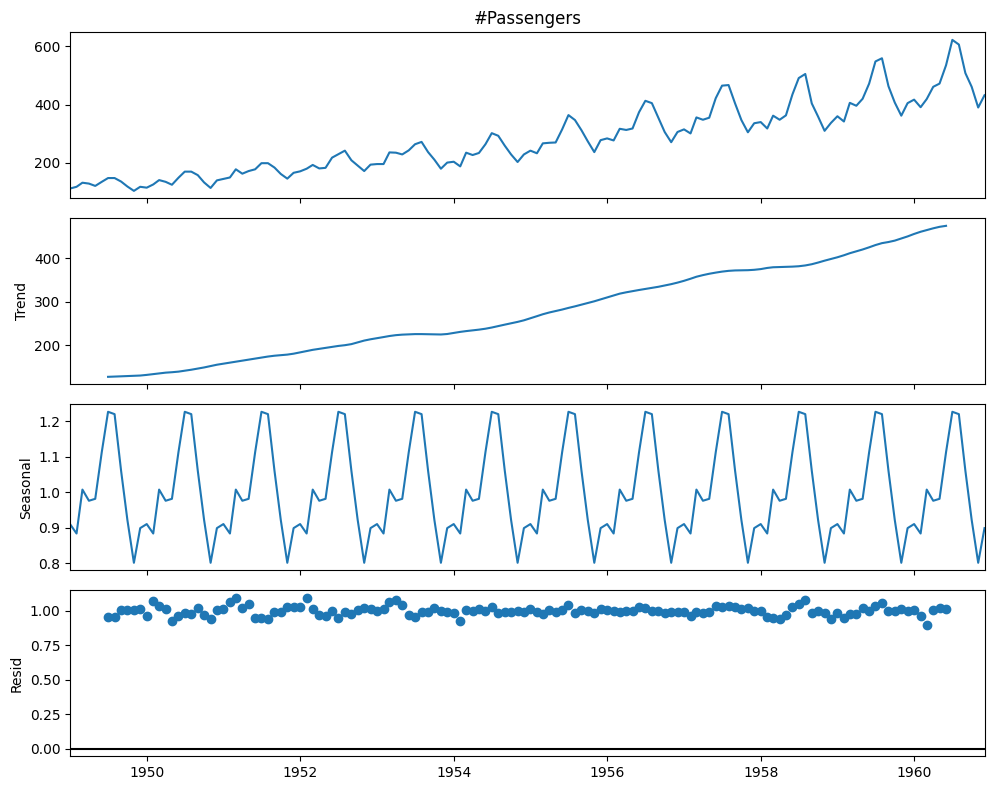

In [50]:
plt.rcParams['figure.figsize'] = (10, 8)
decomposicao.plot()
plt.show()

In [51]:
residuo = decomposicao.resid.dropna()
print('Meses com residuo acima do esperado(picos):')
print(residuo[residuo > 1.05])

print('Meses com residuo abaixo do esperado(vale):')
print(residuo[residuo < 0.95])

Meses com residuo acima do esperado(picos):
Month
1950-02-01    1.071467
1951-02-01    1.064018
1951-03-01    1.091854
1951-05-01    1.051583
1952-02-01    1.093970
1953-03-01    1.060464
1953-04-01    1.080233
1958-08-01    1.078970
1959-08-01    1.053100
Name: resid, dtype: float64
Meses com residuo abaixo do esperado(vale):
Month
1950-05-01    0.926903
1950-11-01    0.938953
1951-06-01    0.946044
1951-07-01    0.947404
1951-08-01    0.939760
1952-07-01    0.946856
1954-02-01    0.923203
1958-03-01    0.946911
1958-04-01    0.938399
1958-12-01    0.940569
1960-03-01    0.894086
Name: resid, dtype: float64
